# Robot Fleet Operation Time Analysis

This notebook calculates and plots the total operation time of the fleet of robots across different simulation runs. The operation time is computed by summing the time each robot spends in the `WORKING` or `OPERATING` state.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
import seaborn as sns

# Set the style for the plots
sns.set_theme(style="whitegrid")

In [7]:
def calculate_operation_time(res_dir="../res"):
    """
    Reads the results of multiple simulation runs and calculates the 
    total operation time of the fleet of robots for each configuration.
    """
    if not os.path.exists(res_dir):
        print(f"Results directory '{res_dir}' not found.")
        return None
        
    report_dirs = glob.glob(os.path.join(res_dir, 'report-*'))
    if not report_dirs:
        print(f"No reports found in '{res_dir}'.")
        return None
        
    operation_times = []
    
    for report_dir in report_dirs:
        config_name = os.path.basename(report_dir)
        total_working_time = 0
        
        # Get all robot CSVs in this run
        robot_files = glob.glob(os.path.join(report_dir, 'robots', 'robot-*.csv'))
        
        for robot_file in robot_files:
            try:
                df = pd.read_csv(robot_file)
                # Count rows where Status is 'WORKING' or 'OPERATING'
                # Assuming 1 row = 1 unit of time
                working_rows = df[df['Status'].isin(['WORKING', 'OPERATING'])]
                total_working_time += len(working_rows)
            except Exception as e:
                print(f"Error reading {robot_file}: {e}")
                
        operation_times.append({
            'Configuration': config_name,
            'Operation Time': total_working_time
        })
        
    results_df = pd.DataFrame(operation_times)
    results_df = results_df.sort_values('Operation Time', ascending=False)
    
    return results_df

# Calculate and display the results
results_df = calculate_operation_time()

if results_df is not None and not results_df.empty:
    display(results_df)

,Configuration,Operation Time
2,report-offloading-descending,45364
1,report-offloading-ascending,44765
0,report-unoffload,44231


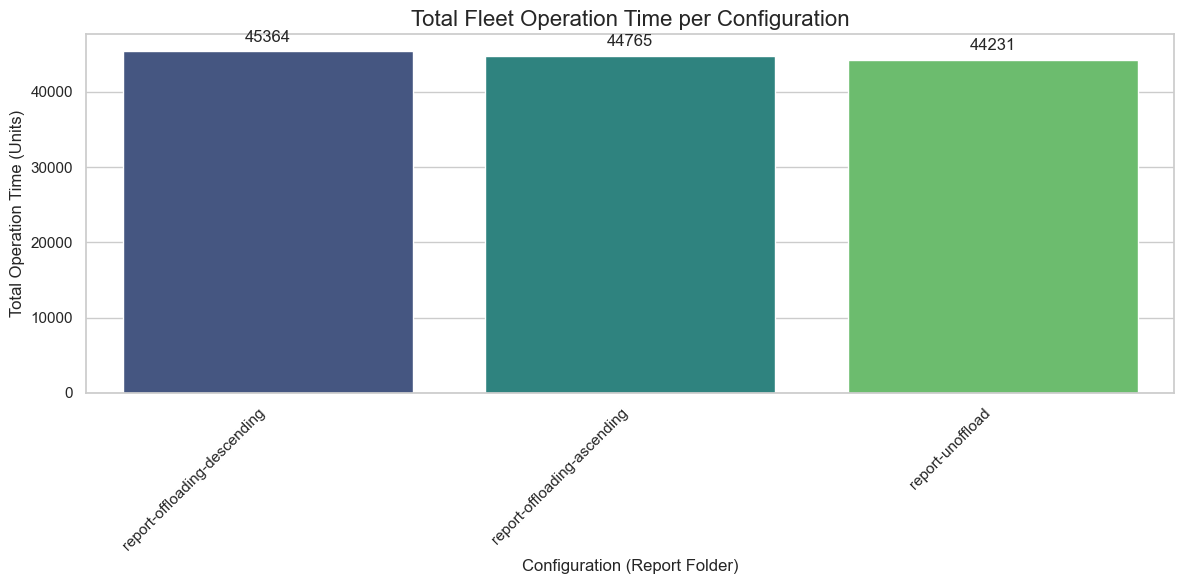

In [8]:
if results_df is not None and not results_df.empty:
    plt.figure(figsize=(12, 6))
    
    # Create bar plot
    ax = sns.barplot(
        data=results_df, 
        x='Configuration', 
        y='Operation Time',
        palette='viridis',
        hue='Configuration', # Add hue to avoid palette without hue warning
        legend=False
    )
    
    plt.title('Total Fleet Operation Time per Configuration', fontsize=16)
    plt.xlabel('Configuration (Report Folder)', fontsize=12)
    plt.ylabel('Total Operation Time (Units)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    
    # Add value labels on top of the bars
    for i, p in enumerate(ax.patches):
        ax.annotate(f"{int(p.get_height())}", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', 
                    xytext=(0, 5), 
                    textcoords='offset points')
                    
    plt.tight_layout()
    plt.savefig('operation_time_comparison.png', dpi=300)
    plt.show()